# 13 · CFTR2 as the benchmark — which variants can *any* tool actually predict?

Notebooks **01–12** each introduced one tool in isolation. This notebook does the thing
those notebooks set up but never finish: take the **entire public CFTR2 variant list**
as the benchmark, run **every predictor in this toolkit** against it, and answer one
blunt question —

> **For how many real CF variants does a prediction even exist, and how good is it?**

The CFTR2 list splits into three parts, and the split is the main result:

| Part | Definition | What lives there |
|---|---|---|
| **1 · missense tools** | ≥ 1 of AlphaMissense / EVE / ESM1b / REVEL / PrimateAI returns a score | single-residue missense |
| **2 · splice tools only** | no missense score, but SpliceAI / Pangolin returns one | intronic, synonymous, and (see §7) every other SNV |
| **3 · no tool at all** | nothing scores it | deletions, insertions, complex alleles — **including F508del** |

Everything is written to `outputs/` at the end (§10).


> ✅ **REAL data throughout.** CFTR2 30 January 2026 (2,097 variants) · AlphaMissense ·
> EVE · ESM1b · REVEL v1.3 · PrimateAI · SpliceAI v1.3 masked-SNV (~566k CFTR SNVs) ·
> live CADD v1.7 API. **One exception: Pangolin is `source='DEMO'`** — `build_pangolin.py`
> runs the real model but only over 5 curated alleles, so its *coverage* is not
> benchmark-scale. Every extract is gitignored; rebuild with the `build_*.py` scripts
> (see `data/README.md`). If an extract is missing, that tool's column is simply empty
> here — the notebook still runs, but the coverage numbers will be wrong.


In [1]:
import sys, pathlib, warnings, re
# `toolkit` is THIS repo's toolkit.py (one directory up) — predict/ sits beside
# notebooks/, so the same sys.path line works here.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

OUT_DIR = tk.OUT_DIR                 # <repo>/outputs — gitignored, regenerated by this notebook
OUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.width", 160)
print("results will be written to:", OUT_DIR)

results will be written to: E:\cftr_variant_toolkit\outputs


## 1 · Why CFTR2 is the right benchmark here — and where it is weak

CFTR2 is the **disease-specific** reference (notebook 08): it labels *CFTR* variants using
**patient outcomes + in-vitro CFTR function assays**. The functional axis is evidence a
sequence model never trained on, which is why it is a better yardstick than ClinVar alone.

Three honest caveats, stated up front because they bound everything below:

1. **Not independent of ClinVar.** CFTR2 and ClinVar share clinical evidence and cross-cite,
   and **REVEL is trained on ClinVar-lineage labels** — so REVEL's numbers here are
   **partly circular** (notebook 12). Treat the unsupervised tools (AlphaMissense, EVE,
   ESM1b) as the cleaner comparison.
2. **Brutal class imbalance.** CFTR2 has ~1,245 *CF-causing* variants and only ~42
   *Non CF-causing* ones. Specificity is therefore estimated from a few dozen variants and
   is *noisy*; accuracy on this set is close to meaningless.
3. **"No interpretation available" is not "benign".** ~722 variants carry that label —
   they are excluded from the accuracy math but kept in the coverage math, because *those*
   are exactly the variants a predictor would be useful for.


In [2]:
cftr2 = tk.load_cftr2()          # REAL — the full 30 January 2026 release
print(f"CFTR2 variants: {len(cftr2):,} | source: {cftr2['source'].unique().tolist()}")
print()
print(cftr2["cftr2_class"].value_counts(dropna=False).to_string())

CFTR2 variants: 2,097 | source: ['REAL']

cftr2_class
CF-causing                      1245
No interpretation available      722
Varying clinical consequence      83
Non CF-causing                    42
NaN                                5


## 2 · Annotate what each variant *is*

Coverage only makes sense against variant class: a missense predictor missing a whole-exon
deletion is not a bug. `build_cftr2.py` already derives a 1-letter `protein_variant` key for
simple missense; here we classify **every** row from its HGVS protein/cDNA name so we can
read the coverage table by class.

Order matters — `del/ins/dup` is tested first because a variant like
`c.2916_2917delinsAT` also carries a missense-looking protein name.


In [3]:
def variant_class(row) -> str:
    """Coarse class from the HGVS names. Checked in order — indel first, because a
    delins can also look like a missense at the protein level."""
    p, c = str(row.get("protein_name") or ""), str(row.get("cdna_name") or "")
    if re.search(r"(del|ins|dup)", c):                     return "indel / large del"
    if "X" in p:                                           return "nonsense"
    if re.match(r"^p\.[A-Z][a-z]{2}\d+[A-Z][a-z]{2}$", p): return "missense"
    if "=" in p:                                           return "synonymous"
    if re.search(r"c\.[\d*-]+[+-]\d+", c):                 return "intronic / splice-region"
    if re.match(r"^c\.-", c):                              return "5' UTR"
    if re.match(r"^c\.\*", c):                             return "3' UTR"
    return "other / complex"

bench = cftr2.copy()
bench["protein_variant"] = bench["protein_variant"].fillna("")
bench["variant_class"]   = bench.apply(variant_class, axis=1)
print(bench["variant_class"].value_counts().to_string())

variant_class
missense                    778
indel / large del           713
intronic / splice-region    270
nonsense                    224
other / complex              62
synonymous                   41
5' UTR                        9


## 3 · Three join keys, one benchmark table

The tools do **not** share an identifier, and this is the single biggest practical obstacle
to a cross-tool comparison:

| Key | Tools | Consequence |
|---|---|---|
| **protein change** (`G551D`) | AlphaMissense, EVE, ESM1b | only exists for simple missense (~780 / 2,097) |
| **genomic coordinate** (`7-117587778-G-T`) | REVEL, PrimateAI, SpliceAI | needs CFTR2's GRCh38 columns — **204 variants have none** |
| **cDNA name** (`c.3718-2477C>T`) | Pangolin (as built here) | the only key that covers every variant class |

CFTR2's GRCh38 coordinates are the authoritative ones (notebook 09 showed the demo table's
hand-entered coords mostly don't reproduce), so we join on those rather than re-deriving them.


In [4]:
bench["chrom"] = "7"
bench["pos"]   = pd.to_numeric(bench["grch38_pos"], errors="coerce")
bench["ref"]   = bench["grch38_ref"].astype("string")
bench["alt"]   = bench["grch38_alt"].astype("string")

def join_protein(frame, loader, col, out):
    """Join a protein-keyed tool. Rows with no missense key get NaN, never a stray match."""
    d = loader()[["protein_variant", col]].dropna(subset=["protein_variant"])
    d = d.drop_duplicates("protein_variant").rename(columns={col: out})
    frame = frame.merge(d, on="protein_variant", how="left")
    frame.loc[frame["protein_variant"] == "", out] = np.nan
    return frame

def join_coord(frame, loader, col, out):
    """Join a coordinate-keyed tool on chrom/pos/ref/alt (GRCh38, from CFTR2)."""
    d = loader()[["chrom", "pos", "ref", "alt", col]].copy()
    d["chrom"] = d["chrom"].astype(str)
    d["pos"]   = pd.to_numeric(d["pos"], errors="coerce")
    d["ref"], d["alt"] = d["ref"].astype("string"), d["alt"].astype("string")
    d = d.drop_duplicates(["chrom", "pos", "ref", "alt"]).rename(columns={col: out})
    return frame.merge(d, on=["chrom", "pos", "ref", "alt"], how="left")

bench = join_protein(bench, tk.load_alphamissense, "am_score",    "AlphaMissense")
bench = join_protein(bench, tk.load_eve,           "eve_score",   "EVE")
bench = join_protein(bench, tk.load_esm1b,         "esm1b_score", "ESM1b")
bench = join_coord(bench,   tk.load_revel,         "revel_score",      "REVEL")
bench = join_coord(bench,   tk.load_primateai,     "primate_ai_score", "PrimateAI")
bench = join_coord(bench,   tk.load_spliceai,      "spliceai_ds_max",  "SpliceAI")

# Pangolin: cDNA-keyed, and DEMO scope (5 curated alleles) — kept so the table is complete.
pg = tk.load_pangolin()
print("Pangolin rows:", len(pg), "| source:", pg["source"].unique().tolist())
bench = bench.merge(pg[["cdna_name", "pangolin_score"]].drop_duplicates("cdna_name")
                      .rename(columns={"pangolin_score": "Pangolin"}),
                    on="cdna_name", how="left")

MISSENSE_TOOLS = ["AlphaMissense", "EVE", "ESM1b", "REVEL", "PrimateAI"]
SPLICE_TOOLS   = ["SpliceAI", "Pangolin"]
print(f"\nbenchmark table: {bench.shape[0]:,} variants x {bench.shape[1]} columns")

Pangolin rows: 5 | source: ['DEMO']

benchmark table: 2,097 variants x 24 columns


### The one variant the protein key silently loses

780 CFTR2 variants carry a 1-letter missense key; **779** find an AlphaMissense score. The
miss is **M470V**, and the reason is worth more than the one row it costs.

CFTR2 names the polymorphism relative to the MANE transcript, where the reference residue is
**M**470. AlphaMissense is keyed on the UniProt P13569 canonical sequence, where the reference
residue is **V**470 — so AlphaMissense lists the *opposite* substitution, `V470M`. Same
polymorphism, reversed polarity, and a string join has no way to notice.


In [5]:
am = tk.load_alphamissense()
print("CFTR2 asks for M470V →", (am["protein_variant"] == "M470V").sum(), "AlphaMissense rows")
print("AlphaMissense has the reverse, V470M →")
print(am[am["protein_variant"] == "V470M"].to_string(index=False))
print("\nCFTR2's own row (note: no GRCh38 coordinates either, so the coord join can't rescue it):")
print(bench.loc[bench["legacy_name"] == "M470V",
                ["legacy_name", "cdna_name", "protein_name", "cftr2_class",
                 "grch38_pos", "AlphaMissense", "REVEL"]].to_string(index=False))

CFTR2 asks for M470V → 0 AlphaMissense rows
AlphaMissense has the reverse, V470M →
protein_variant  am_score      am_class source
          V470M    0.0489 likely_benign   REAL

CFTR2's own row (note: no GRCh38 coordinates either, so the coord join can't rescue it):
legacy_name cdna_name protein_name    cftr2_class  grch38_pos  AlphaMissense  REVEL
      M470V c.1408A>G  p.Met470Val Non CF-causing         NaN            NaN    NaN


## 4 · Per-tool coverage over the whole CFTR2 list

In [6]:
ALL_TOOLS = MISSENSE_TOOLS + SPLICE_TOOLS
cov = pd.DataFrame({
    "tool":     ALL_TOOLS,
    "kind":     ["missense"] * len(MISSENSE_TOOLS) + ["splice"] * len(SPLICE_TOOLS),
    "join_key": ["protein", "protein", "protein", "coordinate", "coordinate",
                 "coordinate", "cDNA name"],
    "scored":   [int(bench[t].notna().sum()) for t in ALL_TOOLS],
})
cov["pct_of_cftr2"] = (100 * cov["scored"] / len(bench)).round(1)
cov["learning"]     = [tk.TOOL_REGISTRY[t]["learning"] for t in ALL_TOOLS]
cov.sort_values("scored", ascending=False, ignore_index=True)

,tool,kind,join_key,scored,pct_of_cftr2,learning
0,SpliceAI,splice,coordinate,1311,62.5,"supervised (on GTEx splice junctions, not clin..."
1,REVEL,missense,coordinate,801,38.2,supervised
2,AlphaMissense,missense,protein,779,37.1,unsupervised
3,ESM1b,missense,protein,779,37.1,unsupervised
4,EVE,missense,protein,764,36.4,unsupervised
5,PrimateAI,missense,coordinate,596,28.4,semi-supervised
6,Pangolin,splice,cDNA name,5,0.2,supervised (on splice usage across species/tis...


**REVEL scores 801 variants but AlphaMissense only 779** — REVEL is *not* better covered
because it is a better tool. It is coordinate-keyed, so it picks up rows whose protein key
CFTR2 never derived (multi-allelic `c.` names, delins). §7 shows what those extra scores
are actually worth.


## 5 · ★ The three parts

The categories are **mutually exclusive and ordered**: a variant goes to *missense tools* if
any missense predictor scores it, otherwise to *splice tools only* if a splice predictor
does, otherwise to *no tool*. The ordering matters because SpliceAI scores essentially every
SNV in the region — without it, the "splice" bucket would swallow most of the missense set
(the overlap is printed below).


In [7]:
bench["n_missense_tools"] = bench[MISSENSE_TOOLS].notna().sum(axis=1)
bench["n_splice_tools"]   = bench[SPLICE_TOOLS].notna().sum(axis=1)
bench["category"] = np.select(
    [bench["n_missense_tools"] >= 1, bench["n_splice_tools"] >= 1],
    ["1. missense tools", "2. splice tools only"],
    default="3. no tool")

n = len(bench)
for cat, cnt in bench["category"].value_counts().sort_index().items():
    print(f"{cat:24s} {cnt:5,d}  ({100*cnt/n:4.1f}%)")
print(f"{'TOTAL':24s} {n:5,d}")
print("\noverlap — scored by a missense tool AND a splice tool:",
      int(((bench.n_missense_tools >= 1) & (bench.n_splice_tools >= 1)).sum()))

1. missense tools          803  (38.3%)
2. splice tools only       510  (24.3%)
3. no tool                 784  (37.4%)
TOTAL                    2,097

overlap — scored by a missense tool AND a splice tool: 801


### Part 3 is the biggest, and it is not an artefact

Read the crosstab by variant class: **711 of 713 deletions/insertions get no score from any
tool in this toolkit**. Missense predictors need an amino-acid substitution; the precomputed
SpliceAI file used here is **masked SNV only** (notebook 09), so indels are absent by
construction — the `masked.indel` release exists but a 0-byte download is a common failure,
and SpliceAI resolves only small indels anyway.


In [8]:
by_class = pd.crosstab(bench["variant_class"], bench["category"], margins=True, margins_name="TOTAL")
by_class

category,1. missense tools,2. splice tools only,3. no tool,TOTAL
variant_class,,,,
5' UTR,0,3,6,9
indel / large del,2,0,711,713
intronic / splice-region,2,266,2,270
missense,777,0,1,778
nonsense,12,203,9,224
other / complex,6,2,54,62
synonymous,4,36,1,41
TOTAL,803,510,784,2097


In [9]:
by_truth = pd.crosstab(bench["cftr2_class"], bench["category"], margins=True, margins_name="TOTAL")
by_truth

category,1. missense tools,2. splice tools only,3. no tool,TOTAL
cftr2_class,,,,
CF-causing,279,350,616,1245
No interpretation available,418,151,153,722
Non CF-causing,33,4,5,42
Varying clinical consequence,73,5,5,83
TOTAL,803,510,779,2092


The row that matters clinically: of the **1,245 CF-causing** variants, roughly **half get no
prediction at all**. A "predictor benchmark" that quietly drops them — as any table keyed on
protein change must — is reporting accuracy on the easy half.


## 6 · Weight by how often the variant is actually *seen*

Variant counts treat F508del and a variant reported in one patient as equal. CFTR2 ships an
allele frequency (`cftr2_af`, the share of CF alleles in its patient cohort), so we can ask
the clinically honest version of the question: **what fraction of CF alleles walking through
a clinic could these tools score?**


In [10]:
bench["cftr2_af"] = pd.to_numeric(bench["cftr2_af"], errors="coerce")
af = bench.dropna(subset=["cftr2_af"])
share = (af.groupby("category")["cftr2_af"].sum() / af["cftr2_af"].sum())
print("share of CF alleles (frequency-weighted), by category:")
for cat, v in share.sort_index().items():
    print(f"  {cat:24s} {100*v:5.1f}%")
print("\ntop uncovered alleles by frequency:")
print(af[af.category == "3. no tool"].nlargest(5, "cftr2_af")
        [["legacy_name", "cdna_name", "variant_class", "cftr2_class", "cftr2_af"]]
        .to_string(index=False))

share of CF alleles (frequency-weighted), by category:
  1. missense tools         13.3%
  2. splice tools only      14.2%
  3. no tool                72.6%

top uncovered alleles by frequency:
legacy_name                      cdna_name     variant_class cftr2_class  cftr2_af
    F508del                 c.1521_1523del indel / large del  CF-causing  0.650683
CFTRdele2,3 c.(53+1_54-1)_(273+1_274-1)del indel / large del  CF-causing  0.006258
  2183AA->G             c.2051_2052delinsG indel / large del  CF-causing  0.004453
    I507del                 c.1519_1521del indel / large del  CF-causing  0.004145
   2184insA                      c.2052dup indel / large del  CF-causing  0.004017


**~73% of CF alleles sit in the no-tool bucket**, and one variant explains most of it:
**F508del**, a 3-bp deletion at ~65% allele frequency. The computational-prediction stack
assembled across notebooks 01–11 cannot say anything about the single most common CF variant
in the world. That is not a flaw in any one tool — it is what the toolkit *is*.


## 7 · Coverage is not competence

A score existing does not mean it means anything. Two examples straight out of the table above:

- **REVEL scores 12 nonsense variants.** REVEL is a missense ensemble; these are stop-gains
  that truncate the protein. The scores run 0.009 → 0.86 — i.e. mostly "benign" for variants
  that are unambiguously CF-causing. They arrive because dbNSFP carries the substitution as
  missense on *some* transcript, and our coordinate join is transcript-blind.
- **SpliceAI scores 666 of the 1,287 truth-set variants**, but most are missense or nonsense
  SNVs it merely blankets. Judging SpliceAI on those is judging a splice model on protein
  biology.

So §8 reports metrics **twice**: naively over everything a tool scored, and restricted to the
variant classes the tool is actually *for*.


In [11]:
bad_revel = bench[(bench["variant_class"] == "nonsense") & bench["REVEL"].notna()]
print(f"nonsense variants carrying a REVEL score: {len(bad_revel)}\n")
print(bad_revel[["legacy_name", "cdna_name", "protein_name", "cftr2_class", "REVEL"]]
      .sort_values("REVEL").to_string(index=False))

nonsense variants carrying a REVEL score: 12

legacy_name           cdna_name protein_name cftr2_class  REVEL
     Y1182X           c.3546C>G   p.Tyr1182X  CF-causing  0.009
     R1128X           c.3382A>T   p.Arg1128X  CF-causing  0.042
     S1178X c.3533C>A|c.3533C>G   p.Ser1178X  CF-causing  0.057
     S1206X           c.3617C>G   p.Ser1206X  CF-causing  0.112
     S1196X c.3587C>A|c.3587C>G   p.Ser1196X  CF-causing  0.113
     W1204X c.3611G>A|c.3612G>A   p.Trp1204X  CF-causing  0.185
     W1089X           c.3266G>A   p.Trp1089X  CF-causing  0.307
     Y1092X c.3276C>A|c.3276C>G   p.Tyr1092X  CF-causing  0.366
     K1165X           c.3493A>T   p.Lys1165X  CF-causing  0.521
     W1145X c.3434G>A|c.3435G>A   p.Trp1145X  CF-causing  0.587
     W1098X c.3293G>A|c.3294G>A   p.Trp1098X  CF-causing  0.737
     W1063X           c.3189G>A   p.Trp1063X  CF-causing  0.860


## 8 · The benchmark itself

Truth set = the CFTR2 variants with a *decided* call: **CF-causing** (positive) vs
**Non CF-causing** (negative). "Varying clinical consequence" and "No interpretation
available" are excluded — they are not benign, and scoring them as such would manufacture
false positives.

Thresholds come from `tk.THRESHOLDS` (each tool's own published cut-point), so the
comparison is "each tool at its recommended operating point", not a re-tuned one.


In [12]:
truth = bench[bench["cftr2_class"].isin(["CF-causing", "Non CF-causing"])].copy()
truth["y"] = (truth["cftr2_class"] == "CF-causing").astype(int)
print(f"truth set: {len(truth):,} variants | CF-causing: {int(truth.y.sum()):,} "
      f"| Non CF-causing: {int((1-truth.y).sum())}")

TOOL_KEY = {"AlphaMissense": "am", "EVE": "eve", "ESM1b": "esm1b",
            "REVEL": "revel", "PrimateAI": "primate_ai"}
SPLICE_CUT = tk.THRESHOLDS["spliceai"]["high"]      # 0.5 = HIGH impact

def flag_pathogenic(frame, tool):
    """Binary 'this tool calls it damaging', at the tool's own published cut-point."""
    if tool in TOOL_KEY:
        return frame[tool].apply(lambda s: tk.call_from_score(s, TOOL_KEY[tool]) == "pathogenic")
    return frame[tool] >= SPLICE_CUT

def metrics(frame, tool, label):
    d = frame.dropna(subset=[tool])
    if d.empty:
        return dict(tool=tool, domain=label, n=0)
    pred = flag_pathogenic(d, tool)
    tp = int((pred & (d.y == 1)).sum()); fp = int((pred & (d.y == 0)).sum())
    fn = int((~pred & (d.y == 1)).sum()); tn = int((~pred & (d.y == 0)).sum())
    return dict(tool=tool, domain=label, n=len(d), TP=tp, FP=fp, FN=fn, TN=tn,
                sensitivity=round(tp / (tp + fn), 3) if tp + fn else np.nan,
                specificity=round(tn / (tn + fp), 3) if tn + fp else np.nan)

naive = pd.DataFrame([metrics(truth, t, "everything it scored") for t in ALL_TOOLS])
naive

truth set: 1,287 variants | CF-causing: 1,245 | Non CF-causing: 42


,tool,domain,n,TP,FP,FN,TN,sensitivity,specificity
0,AlphaMissense,everything it scored,292,243,6,16,27,0.938,0.818
1,EVE,everything it scored,291,253,20,5,13,0.981,0.394
2,ESM1b,everything it scored,292,239,9,20,24,0.923,0.727
3,REVEL,everything it scored,312,236,11,43,22,0.846,0.667
4,PrimateAI,everything it scored,245,43,0,170,32,0.202,1.000
5,SpliceAI,everything it scored,666,167,0,462,37,0.266,1.000
6,Pangolin,everything it scored,5,4,0,1,0,0.800,NaN


Now the same tools, each restricted to its own domain — missense predictors on missense
variants, splice predictors on non-coding/synonymous variants.


In [13]:
MISSENSE_DOMAIN = ["missense"]
SPLICE_DOMAIN   = ["intronic / splice-region", "synonymous", "5' UTR", "3' UTR"]
mis_truth = truth[truth["variant_class"].isin(MISSENSE_DOMAIN)]
spl_truth = truth[truth["variant_class"].isin(SPLICE_DOMAIN)]
print(f"missense domain: {len(mis_truth):3d} variants ({int(mis_truth.y.sum())} CF-causing / "
      f"{int((1-mis_truth.y).sum())} not)")
print(f"splice domain:   {len(spl_truth):3d} variants ({int(spl_truth.y.sum())} CF-causing / "
      f"{int((1-spl_truth.y).sum())} not)")

perf = pd.DataFrame(
    [metrics(mis_truth, t, "missense only") for t in MISSENSE_TOOLS] +
    [metrics(spl_truth, t, "non-coding only") for t in SPLICE_TOOLS])
perf

missense domain: 293 variants (259 CF-causing / 34 not)
splice domain:   158 variants (154 CF-causing / 4 not)


,tool,domain,n,TP,FP,FN,TN,sensitivity,specificity
0,AlphaMissense,missense only,292,243,6,16,27,0.938,0.818
1,EVE,missense only,291,253,20,5,13,0.981,0.394
2,ESM1b,missense only,292,239,9,20,24,0.923,0.727
3,REVEL,missense only,292,235,11,24,22,0.907,0.667
4,PrimateAI,missense only,245,43,0,170,32,0.202,1.000
5,SpliceAI,non-coding only,158,149,0,5,4,0.968,1.000
6,Pangolin,non-coding only,5,4,0,1,0,0.800,NaN


### Reading this table honestly

- **SpliceAI is the standout** — ~0.97 sensitivity at DS_max ≥ 0.5 *in its own domain*, versus
  0.27 when judged on everything it happened to score. The naive row is a measurement artefact;
  the restricted row is the result.
- **AlphaMissense has the best missense balance** (~0.94 sens / ~0.82 spec) and is
  label-unsupervised, so it is the least circular of the five.
- **EVE catches nearly everything but calls almost everything damaging** — high sensitivity,
  ~0.39 specificity. On a VUS list that is a lot of false alarms.
- **REVEL's numbers are the least trustworthy here** — not because they look bad, but because
  REVEL is trained on ClinVar-lineage labels that CFTR2 correlates with (notebook 12). It is
  partly grading its own homework.
- **PrimateAI looks broken and isn't.** Its published cut-point (0.803) is far above where its
  CF-causing scores actually sit (median ~0.72), so it calls ~80% of true CF variants benign at
  that threshold. It is a *threshold* mismatch on this gene, not a scoring failure — the
  distribution below makes that visible, and it is exactly why graded, gene-aware thresholds
  (Pejaver 2022) beat one global cut.
- **Specificity everywhere rests on ≤ 34 negatives.** Do not rank tools by it.


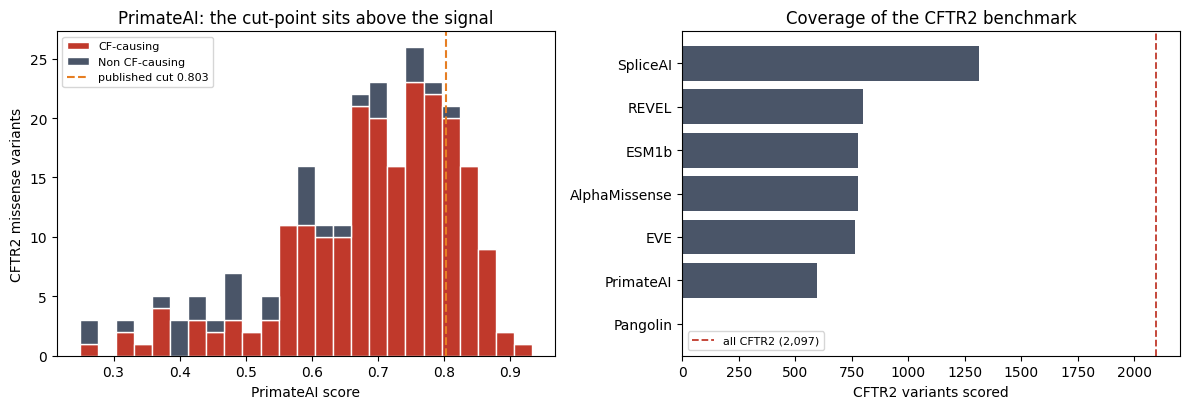

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

d = mis_truth.dropna(subset=["PrimateAI"])
axes[0].hist([d.loc[d.y == 1, "PrimateAI"], d.loc[d.y == 0, "PrimateAI"]], bins=25,
             stacked=True, color=["#c0392b", "#4a5568"], edgecolor="white",
             label=["CF-causing", "Non CF-causing"])
axes[0].axvline(tk.THRESHOLDS["primate_ai"]["path"], ls="--", color="#e67e22", lw=1.5,
                label="published cut 0.803")
axes[0].set_xlabel("PrimateAI score"); axes[0].set_ylabel("CFTR2 missense variants")
axes[0].set_title("PrimateAI: the cut-point sits above the signal"); axes[0].legend(fontsize=8)

order = cov.sort_values("scored")["tool"]
axes[1].barh(order, [int(bench[t].notna().sum()) for t in order], color="#4a5568")
axes[1].axvline(len(bench), ls="--", color="#c0392b", lw=1.3, label=f"all CFTR2 ({len(bench):,})")
axes[1].set_xlabel("CFTR2 variants scored"); axes[1].set_title("Coverage of the CFTR2 benchmark")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "predict_coverage.png", dpi=150)
plt.show()

## 9 · Can CADD rescue any of part 3?

CADD is the one general-purpose scorer in the toolkit — it is not restricted to missense or to
splicing, so in principle it reaches variants the others cannot. In practice its ceiling here
is the same one: the CADD REST API returns **substitutions**, so of the 784 uncovered variants
it can only reach the handful that are SNVs — the 5′ UTR ones. The 711 deletions/insertions
stay unreachable.

This is a **live API** (notebook 11), so the cell is bounded and defensive: a few variants, and
a network failure degrades to empty rather than breaking the notebook.


In [15]:
uncovered = bench[bench["category"] == "3. no tool"].copy()
is_snv = uncovered["ref"].str.len().eq(1) & uncovered["alt"].str.len().eq(1)
rescuable = uncovered[is_snv.fillna(False)]
print(f"uncovered variants: {len(uncovered):,}")
print(f"  ... with GRCh38 coordinates: {int(uncovered['pos'].notna().sum()):,}")
print(f"  ... and a single-nucleotide substitution CADD could score: {len(rescuable)}")
print(f"  ... indels/large deletions, unreachable by every tool here: "
      f"{int((uncovered['variant_class'] == 'indel / large del').sum()):,}")

rows = []
for _, v in rescuable.iterrows():
    r = tk.fetch_cadd("7", int(v["pos"]), v["ref"], v["alt"])
    rows.append({"legacy_name": v["legacy_name"], "cdna_name": v["cdna_name"],
                 "variant_class": v["variant_class"], "cftr2_class": v["cftr2_class"],
                 "cadd_phred": r.get("cadd_phred")})
cadd_rescue = pd.DataFrame(rows)
if not cadd_rescue.empty:
    cadd_rescue["cadd_call"] = np.where(
        cadd_rescue["cadd_phred"] >= tk.THRESHOLDS["cadd"]["path"], "top 3% (>=15)", "below cut")
cadd_rescue

uncovered variants: 784
  ... with GRCh38 coordinates: 580
  ... and a single-nucleotide substitution CADD could score: 6
  ... indels/large deletions, unreachable by every tool here: 711


,legacy_name,cdna_name,variant_class,cftr2_class,cadd_phred,cadd_call
0,5UTR-94G->T,c.-226G>T,5' UTR,No interpretation available,17.600,top 3% (>=15)
1,5UTR-448A->G,c.-448A>G,5' UTR,No interpretation available,2.971,below cut
2,5UTR-741T->G,c.-812T>G,5' UTR,No interpretation available,3.680,below cut
3,5UTR-102T->A,c.-234T>A,5' UTR,No interpretation available,14.970,below cut
4,5UTR-33G->A,c.-165G>A,5' UTR,No interpretation available,15.310,top 3% (>=15)
5,5UTR-816C->T,c.-887C>T,5' UTR,No interpretation available,6.987,below cut


So CADD converts a rounding error's worth of part 3 into scored variants. **The gap in part 3
is not a tooling gap this toolkit can close** — closing it needs a different class of evidence
entirely: functional assays, RNA studies, or the CFTR2 patient data itself.


## 10 · Write the results to `outputs/`

`outputs/` is gitignored (like `data/`), so these files are **regenerated, never committed** —
re-run this notebook to rebuild them. The notebook itself ships with its executed cells, so the
numbers stay readable without the data.


In [16]:
KEEP = ["legacy_name", "cdna_name", "protein_name", "protein_variant", "variant_class",
        "cftr2_class", "cftr2_af", "grch38_pos", "grch38_ref", "grch38_alt",
        *ALL_TOOLS, "n_missense_tools", "n_splice_tools", "category"]
master = bench[KEEP].sort_values(["category", "variant_class", "legacy_name"])

summary = (bench.groupby(["category", "variant_class"]).size()
                .rename("n_variants").reset_index())

written = {
    "predict_cftr2_benchmark_ALL.csv":   master,
    "predict_part1_missense_tools.csv":  master[master.category == "1. missense tools"],
    "predict_part2_splice_tools_only.csv": master[master.category == "2. splice tools only"],
    "predict_part3_no_tool.csv":         master[master.category == "3. no tool"],
    "predict_tool_coverage.csv":         cov,
    "predict_tool_performance.csv":      pd.concat([naive, perf], ignore_index=True),
    "predict_category_summary.csv":      summary,
}
if not cadd_rescue.empty:
    written["predict_cadd_rescue.csv"] = cadd_rescue

for name, frame in written.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"{name:38s} {len(frame):5,d} rows")
print(f"{'predict_coverage.png':38s} (figure)")
print("\nall written to:", OUT_DIR)

predict_cftr2_benchmark_ALL.csv        2,097 rows
predict_part1_missense_tools.csv         803 rows
predict_part2_splice_tools_only.csv      510 rows
predict_part3_no_tool.csv                784 rows


predict_tool_coverage.csv                  7 rows
predict_tool_performance.csv              14 rows
predict_category_summary.csv              18 rows
predict_cadd_rescue.csv                    6 rows
predict_coverage.png                   (figure)

all written to: E:\cftr_variant_toolkit\outputs


## Key takeaways

1. **The CFTR2 list splits ~38% / ~24% / ~37%** across *missense tools* (803), *splice tools
   only* (510), and *no tool at all* (784).
2. **Weighted by allele frequency the split collapses**: ~73% of CF alleles fall in the
   no-tool bucket, because **F508del** — a deletion, at ~65% allele frequency — is invisible to
   every predictor here.
3. **Half of all CF-causing variants (616 / 1,245) get no prediction.** Any benchmark keyed on
   protein change is silently reporting accuracy on the easy half.
4. **Restrict a tool to its domain before judging it.** SpliceAI goes from 0.27 to ~0.97
   sensitivity when it stops being graded on missense variants it merely happened to blanket.
5. **Coverage ≠ competence** — REVEL emits scores for 12 nonsense variants, mostly "benign";
   PrimateAI's published cut-point sits above where its CF-causing scores actually live.
6. **Rank tools by sensitivity, not accuracy or specificity here** — 42 negatives cannot
   support the other two, and REVEL's agreement is partly circular (notebook 12).

**Where this leaves the toolkit:** notebooks 01–12 answer *how does each tool work*; this one
answers *what is still unanswerable*. The honest headline is the third bucket.
